# 02｜从伯禹 PPO 到 VERL：手撕 PPO、GRPO、DPO

> 学习目标：先看懂算法张量，再回到 VERL 看工程调度。这里不复刻 Ray、FSDP、vLLM，只复刻决定梯度方向的核心数学。

学完后你应该能回答：

1. `old_log_probs`、`log_probs`、`advantages` 为什么形状相同？
2. PPO 为什么需要 critic，而 GRPO 不需要？
3. DPO 为什么既没有 rollout，也没有 advantage？


## 0. 先建立一张总地图

| 算法 | 训练数据 | 核心比较 | critic | 是否在线生成 |
|---|---|---|---|---|
| PPO | prompt + rollout + reward | 新策略 vs 采样时旧策略 | 需要 | 是 |
| GRPO | 同一 prompt 的多条 rollout + reward | 新旧策略；组内相对奖励 | 不需要 | 是 |
| DPO | chosen / rejected 偏好对 | policy 偏好差 vs reference 偏好差 | 不需要 | 否 |

伯禹教程里，一个 CartPole 动作对应一个 `log_prob`。在 LLM 中，一次回答有很多 token，所以 VERL 中常见张量是 `[batch, response_length]`：每个回答 token 都相当于一个动作。`response_mask` 决定哪些位置是真的回答，哪些只是 padding。


## 1. 与本机 VERL 0.8.0 的源码映射

本 Notebook 对齐这些函数：

- `verl/trainer/ppo/core_algos.py:216`：`compute_gae_advantage_return`
- `verl/trainer/ppo/core_algos.py:268`：`compute_grpo_outcome_advantage`
- `verl/trainer/ppo/core_algos.py:1278`：`compute_policy_loss_vanilla`
- `verl/trainer/ppo/core_algos.py:2083`：`compute_value_loss`
- `verl/trainer/ppo/core_algos.py:2125`：`kl_penalty`
- `verl/workers/utils/losses.py`：把模型算出的 `log_prob` 和 batch 字段送入上述损失。

注意：本机 VERL 包中没有标准 DPO trainer。因此 DPO 部分按原论文公式独立实现，不伪装成 VERL 源码复刻。


In [ ]:
from dataclasses import dataclass
from typing import Dict, Tuple

import torch
import torch.nn.functional as F

torch.manual_seed(42)

def masked_mean(x: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """只统计 response token；padding 不参与平均。"""
    mask = mask.to(dtype=x.dtype)
    return (x * mask).sum() / mask.sum().clamp_min(eps)


def masked_whiten(x: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """对应 VERL 的 masked_whiten：把有效 token 的 advantage 标准化。"""
    mean = masked_mean(x, mask, eps)
    var = masked_mean((x - mean) ** 2, mask, eps)
    return (x - mean) * torch.rsqrt(var + eps) * mask.to(x.dtype)


## 2. HandwrittenPPO

伯禹 PPO 的主线是：`TD target → advantage → old_log_prob → ratio → clip → actor/critic 更新`。下面把它改造成 LLM token 版本，并补上 VERL 使用的 value clipping。

最重要的一行仍然是：`ratio = exp(new_log_prob - old_log_prob)`。如果 ratio 为 1，说明当前策略对这个已采样 token 的概率还没变。


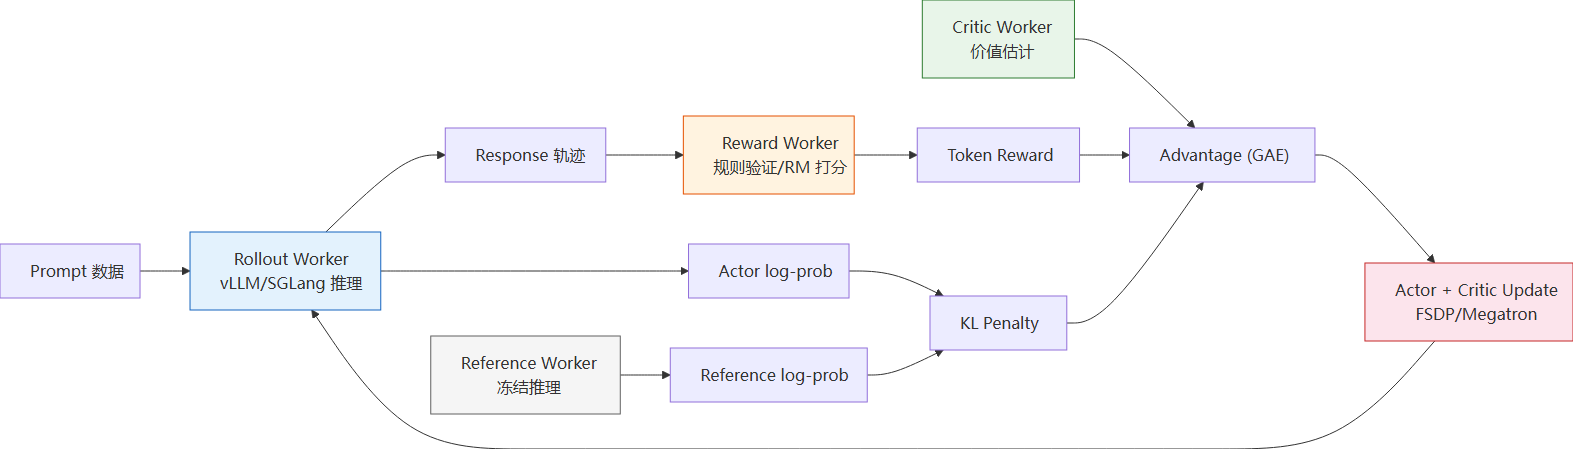

In [ ]:
@dataclass
class PPOConfig:
    gamma: float = 1.0
    gae_lambda: float = 0.95
    clip_ratio: float = 0.2
    value_clip: float = 0.2
    value_coef: float = 0.5
    entropy_coef: float = 0.0

# token 级别的PPO
class HandwrittenPPO:
    """面向 LLM response token 的最小 PPO 数学核心。

    这个类不负责 generate，也不绑定某个 Transformer。它接收模型已经算好的
    log probabilities / values，这正是穿过 VERL 工程外壳后的算法接口。
    """

    def __init__(self, config: PPOConfig = PPOConfig()):
        self.cfg = config

    @torch.no_grad()
    def compute_gae(
        self,
        token_rewards: torch.Tensor, # 对于每个tokne都会有一个奖励， batchsize， response length
        old_values: torch.Tensor,
        response_mask: torch.Tensor, # 掩码，标记哪些是真实生成的 Token，哪些是 Padding 填充
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """从后往前递推 GAE；三者形状均为 [B, T]。"""
        batch_size, response_length = token_rewards.shape
        advantages = torch.zeros_like(token_rewards) # 对于每一个token都会有个GAE
        next_value = torch.zeros(batch_size, device=token_rewards.device, dtype=token_rewards.dtype)
        last_gae = torch.zeros_like(next_value)

        for t in reversed(range(response_length)):
            valid = response_mask[:, t].bool() # 当前这个token是否是padding，不是就是1， 是就是0
            delta = token_rewards[:, t] + self.cfg.gamma * next_value - old_values[:, t] # TD计算公式 ：delta = R + γ * V(s') - V(s)
            candidate_gae = delta + self.cfg.gamma * self.cfg.gae_lambda * last_gae # GAE公式 ：GAE = delta + γ * λ * GAE(s')

            # where函数 ，如果valid = 1 ， 那么就给old value， 如果为 0 就给next value
            # 这相当于在padding的地方，直接把GAE和next value都置为0， 因为padding不参与计算
            next_value = torch.where(valid, old_values[:, t], next_value)
            last_gae = torch.where(valid, candidate_gae, last_gae)
            advantages[:, t] = torch.where(valid, last_gae, torch.zeros_like(last_gae))

        # VERL 先用未标准化 advantage 得到 return，再单独 whiten advantage。
        returns = advantages + old_values

        
        advantages = masked_whiten(advantages, response_mask)
        return advantages, returns

    def policy_loss(
        self,
        new_log_probs: torch.Tensor,
        old_log_probs: torch.Tensor,
        advantages: torch.Tensor,
        response_mask: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        log_ratio = torch.clamp(new_log_probs - old_log_probs, -20.0, 20.0)
        ratio = torch.exp(log_ratio)

        loss_unclipped = -advantages * ratio
        ratio_clipped = torch.clamp(ratio, 1 - self.cfg.clip_ratio, 1 + self.cfg.clip_ratio)
        loss_clipped = -advantages * ratio_clipped
        token_loss = torch.maximum(loss_unclipped, loss_clipped)
        policy_loss = masked_mean(token_loss, response_mask)

        metrics = {
            "ratio_mean": masked_mean(ratio, response_mask).detach(),
            "clip_fraction": masked_mean((loss_clipped > loss_unclipped).float(), response_mask).detach(),
            "approx_kl": masked_mean(old_log_probs - new_log_probs, response_mask).detach(),
        }
        return policy_loss, metrics

    def value_loss(
        self,
        new_values: torch.Tensor,
        old_values: torch.Tensor,
        returns: torch.Tensor,
        response_mask: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        clipped_values = old_values + torch.clamp(
            new_values - old_values, -self.cfg.value_clip, self.cfg.value_clip
        )
        loss_unclipped = (new_values - returns) ** 2
        loss_clipped = (clipped_values - returns) ** 2
        value_loss = 0.5 * masked_mean(torch.maximum(loss_unclipped, loss_clipped), response_mask)
        clip_fraction = masked_mean((loss_clipped > loss_unclipped).float(), response_mask).detach()
        return value_loss, clip_fraction

    def loss(
        self, new_log_probs, old_log_probs, advantages,
        new_values, old_values, returns, response_mask, entropy=None
    ):
        pg_loss, metrics = self.policy_loss(new_log_probs, old_log_probs, advantages, response_mask)
        vf_loss, vf_clip_fraction = self.value_loss(new_values, old_values, returns, response_mask)
        entropy_mean = torch.tensor(0.0, device=new_log_probs.device)
        if entropy is not None:
            entropy_mean = masked_mean(entropy, response_mask)
            
        # value_coef 是 value loss 的权重，防止critic 收敛太快，导致actor以为自己训练的很好 
        total = pg_loss + self.cfg.value_coef * vf_loss - self.cfg.entropy_coef * entropy_mean
        metrics.update({
            "policy_loss": pg_loss.detach(),
            "value_loss": vf_loss.detach(),
            "value_clip_fraction": vf_clip_fraction,
            "total_loss": total.detach(),
        })
        return total, metrics


### PPO 最小运行测试

这里故意不用真实大模型。`new_log_probs` 和 `new_values` 被当作模型当前输出，只验证 loss 能否反传。真实训练时，它们来自 Transformer forward。


In [ ]:
B, T = 2, 5
response_mask = torch.tensor([[1, 1, 1, 1, 0], [1, 1, 1, 0, 0]], dtype=torch.float32)
old_log_probs = torch.tensor([[-1.2, -0.8, -1.4, -0.5, 0.0], [-0.7, -1.1, -0.9, 0.0, 0.0]])
old_values = torch.zeros(B, T)
token_rewards = torch.tensor([[0, 0, 0, 1.0, 0], [0, 0, -0.3, 0, 0]], dtype=torch.float32)

ppo = HandwrittenPPO()
advantages, returns = ppo.compute_gae(token_rewards, old_values, response_mask)

new_log_probs = torch.nn.Parameter(old_log_probs + 0.05 * torch.randn(B, T))
new_values = torch.nn.Parameter(old_values + 0.05 * torch.randn(B, T))
total_loss, ppo_metrics = ppo.loss(
    new_log_probs, old_log_probs, advantages,
    new_values, old_values, returns, response_mask
)
total_loss.backward()

assert torch.isfinite(total_loss)
assert new_log_probs.grad is not None and new_values.grad is not None
print("advantages =\n", advantages)
print({k: round(v.item(), 6) for k, v in ppo_metrics.items()})
print("PPO backward: OK")


## 3. HandwrittenGRPO

GRPO 并没有推翻 PPO-Clip。它主要替换了 advantage 的来源：

- PPO：critic 预测 value，再用 GAE 得到 advantage。
- GRPO：同一个 prompt 采样多条回答，用组内 reward 均值（通常再除标准差）作为 baseline。

所以 VERL 的 GRPO 仍沿用 PPO actor loss 和许多 `ppo_` 配置名，只把 `adv_estimator` 换成 `grpo` 并跳过 critic。


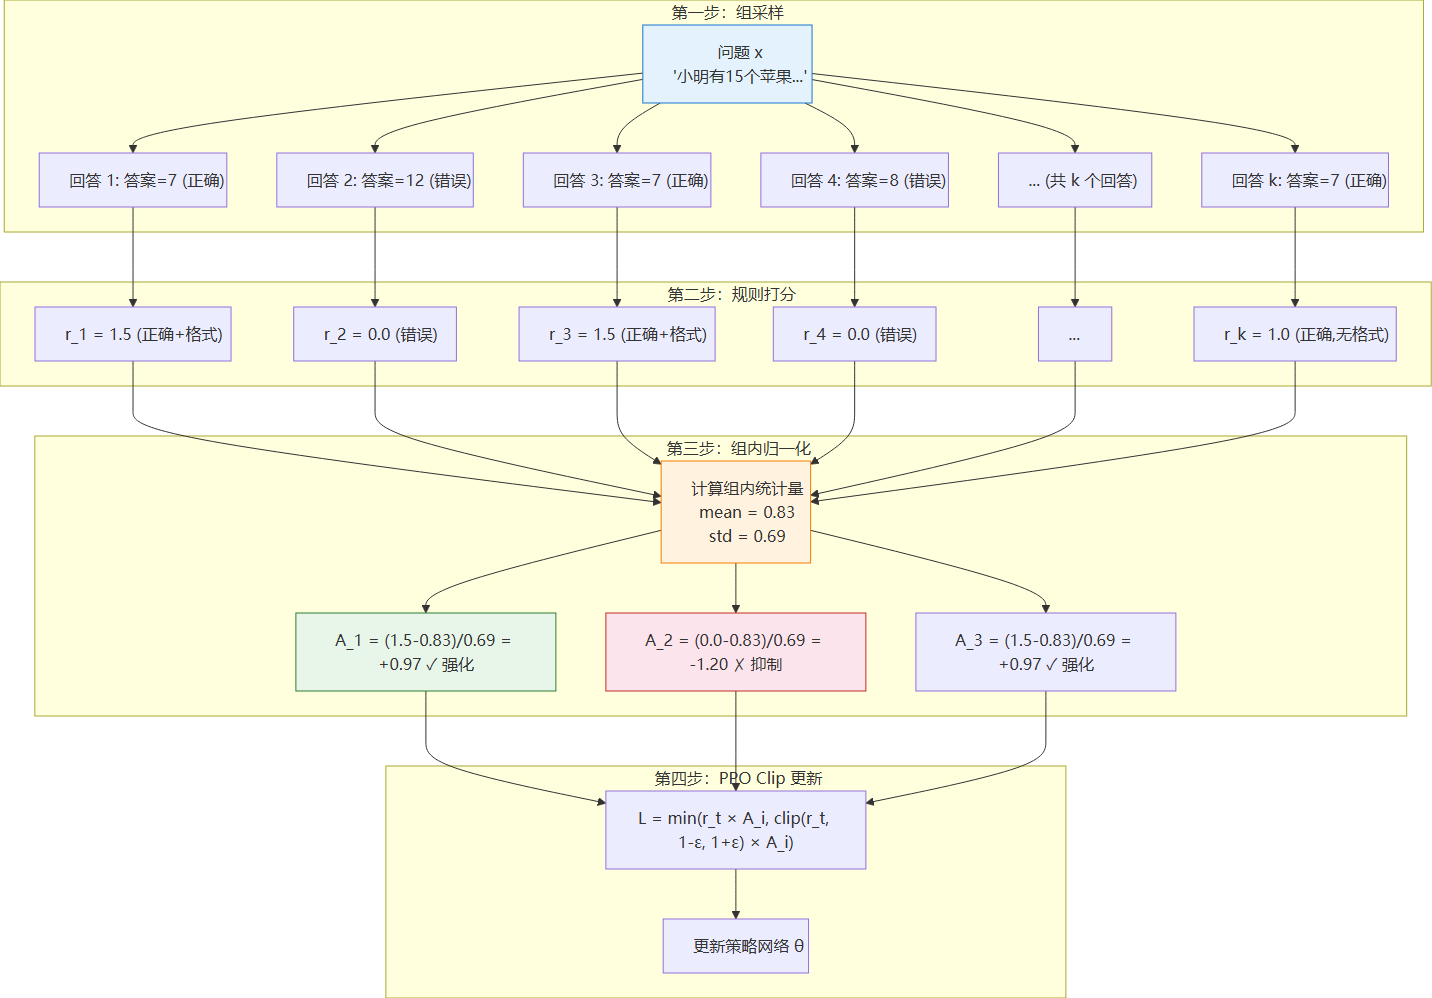

In [ ]:
@dataclass
class GRPOConfig:
    clip_ratio: float = 0.2
    kl_coef: float = 0.001
    normalize_by_std: bool = True
    eps: float = 1e-6


class HandwrittenGRPO:
    def __init__(self, config: GRPOConfig = GRPOConfig()):
        self.cfg = config
        self._ppo_loss = HandwrittenPPO(PPOConfig(clip_ratio=config.clip_ratio))

    @torch.no_grad()
    def compute_group_advantages(
        self, token_rewards: torch.Tensor, response_mask: torch.Tensor, group_ids: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """group_ids 相同表示这些回答来自同一个 prompt。"""
        scores = (token_rewards * response_mask).sum(dim=-1)
        relative_scores = torch.zeros_like(scores)

        for group_id in torch.unique(group_ids):
            in_group = group_ids == group_id
            group_scores = scores[in_group]
            if group_scores.numel() < 2:
                raise ValueError("GRPO 每个 prompt 至少需要两条回答，否则没有组内相对基线。")
            centered = group_scores - group_scores.mean()
            if self.cfg.normalize_by_std:
                centered = centered / (group_scores.std(unbiased=True) + self.cfg.eps)
            relative_scores[in_group] = centered

        # 这里让response mask 为了让token advantages 只在有效 token 上有值
        token_advantages = relative_scores.unsqueeze(-1) * response_mask
        return token_advantages, scores

    # 用泰勒展开来将kl散度的方差减小更加方便训练 
    @staticmethod
    def k3_kl(new_log_probs: torch.Tensor, ref_log_probs: torch.Tensor) -> torch.Tensor:
        """VERL low_var_kl / k3 的逐 token 近似。"""
        log_ref_over_policy = torch.clamp(ref_log_probs - new_log_probs, -20.0, 20.0)
        return torch.exp(log_ref_over_policy) - log_ref_over_policy - 1.0

    def loss(
        self, new_log_probs, old_log_probs, ref_log_probs, advantages, response_mask
    ):
        pg_loss, metrics = self._ppo_loss.policy_loss(
            new_log_probs, old_log_probs, advantages, response_mask
        )
        kl_loss = masked_mean(self.k3_kl(new_log_probs, ref_log_probs), response_mask)
        total = pg_loss + self.cfg.kl_coef * kl_loss
        metrics.update({"kl_loss": kl_loss.detach(), "total_loss": total.detach()})
        return total, metrics


In [ ]:
# 两个 prompt，每个 prompt 采样 3 条回答，因此 B = 6。
B, T = 6, 4
group_ids = torch.tensor([0, 0, 0, 1, 1, 1])
response_mask = torch.tensor([
    [1, 1, 1, 1], [1, 1, 1, 0], [1, 1, 0, 0],
    [1, 1, 1, 1], [1, 1, 1, 1], [1, 1, 1, 0],
], dtype=torch.float32)
sequence_rewards = torch.tensor([1.0, 0.2, -0.5, 0.0, 0.8, 0.4])
token_rewards = torch.zeros(B, T)
for i in range(B):
    last_token = int(response_mask[i].sum().item()) - 1
    token_rewards[i, last_token] = sequence_rewards[i]

grpo = HandwrittenGRPO()
grpo_advantages, raw_scores = grpo.compute_group_advantages(token_rewards, response_mask, group_ids)
old_log_probs = -1.0 + 0.1 * torch.randn(B, T)
ref_log_probs = old_log_probs - 0.03 * torch.randn(B, T)
new_log_probs = torch.nn.Parameter(old_log_probs + 0.05 * torch.randn(B, T))
grpo_loss, grpo_metrics = grpo.loss(
    new_log_probs, old_log_probs, ref_log_probs, grpo_advantages, response_mask
)
grpo_loss.backward()

assert torch.isfinite(grpo_loss) and new_log_probs.grad is not None
print("sequence scores:", raw_scores.tolist())
print("relative advantage:", grpo_advantages[:, 0].tolist())
print({k: round(v.item(), 6) for k, v in grpo_metrics.items()})
print("GRPO backward: OK")


## 4. HandwrittenDPO

DPO 是另一条路线，不是把 PPO 的 advantage 再换一次。数据已经告诉模型 `chosen` 比 `rejected` 好，因此无需在线 rollout、reward model、critic 或 GAE。

先把回答 token 的 log probability 求和，得到整条回答的 log probability。再比较：当前 policy 对 chosen/rejected 的偏好差，是否比 reference model 更大。


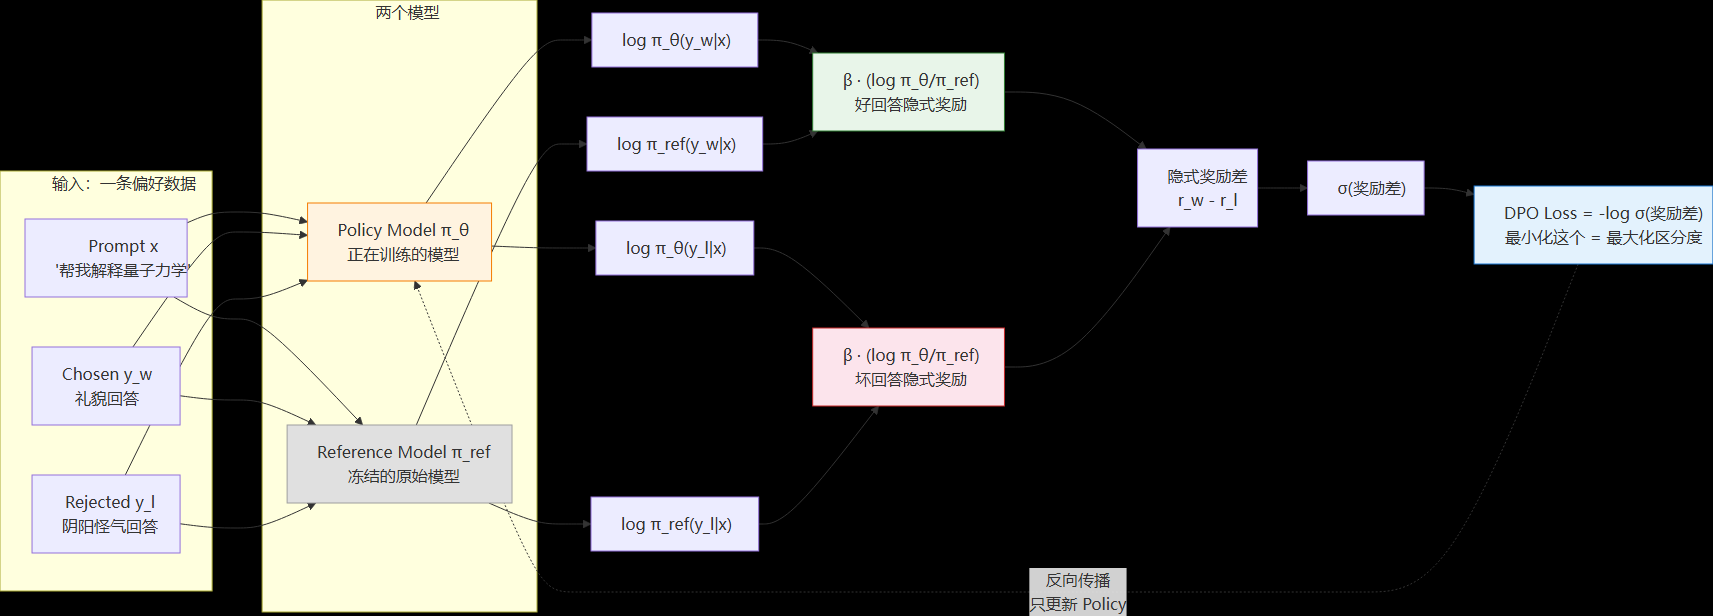

In [ ]:
@dataclass
class DPOConfig:
    beta: float = 0.1


class HandwrittenDPO:
    def __init__(self, config: DPOConfig = DPOConfig()):
        self.cfg = config

    @staticmethod
    def sequence_log_prob(token_log_probs: torch.Tensor, response_mask: torch.Tensor) -> torch.Tensor:
        """DPO 原始目标通常对 response token 的 log probability 求和。"""
        return (token_log_probs * response_mask).sum(dim=-1)

    def loss(
        self,
        policy_chosen_token_logps: torch.Tensor,
        policy_rejected_token_logps: torch.Tensor,
        ref_chosen_token_logps: torch.Tensor,
        ref_rejected_token_logps: torch.Tensor,
        chosen_mask: torch.Tensor,
        rejected_mask: torch.Tensor,
    ):
        policy_chosen = self.sequence_log_prob(policy_chosen_token_logps, chosen_mask)
        policy_rejected = self.sequence_log_prob(policy_rejected_token_logps, rejected_mask)
        ref_chosen = self.sequence_log_prob(ref_chosen_token_logps, chosen_mask).detach()
        ref_rejected = self.sequence_log_prob(ref_rejected_token_logps, rejected_mask).detach()

        policy_log_ratio = policy_chosen - policy_rejected
        ref_log_ratio = ref_chosen - ref_rejected
        preference_logits = self.cfg.beta * (policy_log_ratio - ref_log_ratio)
        per_pair_loss = -F.logsigmoid(preference_logits)
        loss = per_pair_loss.mean()

        metrics = {
            "loss": loss.detach(),
            "preference_accuracy": (preference_logits > 0).float().mean().detach(),
            "preference_margin": preference_logits.mean().detach(),
        }
        return loss, metrics


In [ ]:
B, T = 3, 5
chosen_mask = torch.tensor([[1, 1, 1, 1, 0], [1, 1, 1, 0, 0], [1, 1, 1, 1, 1]], dtype=torch.float32)
rejected_mask = torch.tensor([[1, 1, 1, 0, 0], [1, 1, 1, 1, 0], [1, 1, 1, 0, 0]], dtype=torch.float32)
ref_chosen = -1.2 + 0.1 * torch.randn(B, T)
ref_rejected = -1.2 + 0.1 * torch.randn(B, T)
policy_chosen = torch.nn.Parameter(ref_chosen + 0.05 * torch.randn(B, T))
policy_rejected = torch.nn.Parameter(ref_rejected + 0.05 * torch.randn(B, T))

dpo = HandwrittenDPO(DPOConfig(beta=0.1))
dpo_loss, dpo_metrics = dpo.loss(
    policy_chosen, policy_rejected, ref_chosen, ref_rejected, chosen_mask, rejected_mask
)
dpo_loss.backward()

assert torch.isfinite(dpo_loss)
assert policy_chosen.grad is not None and policy_rejected.grad is not None
print({k: round(v.item(), 6) for k, v in dpo_metrics.items()})
print("DPO backward: OK")


## 5. 学习检查站

先不看答案，口头回答：

1. `old_log_probs` 为什么必须固定？如果它也跟着反向传播会怎样？
2. advantage 为正时，PPO 希望提高还是降低对应 token 的概率？
3. 为什么 GRPO 的同组回答必须来自同一个 prompt？
4. DPO 中 reference model 的作用是什么？
5. `response_mask` 漏掉会造成什么问题？

<details><summary>核对答案</summary>

1. 它表示采样数据的行为策略，是重要性比率的固定分母；一起更新会破坏 PPO 目标的含义。
2. 提高，但 ratio 超出 clip 区间后不再继续奖励过大的变化。
3. 组均值必须是同一道问题下可比较回答的 baseline。
4. 给偏好强度提供锚点，限制 policy 相对参考策略的漂移。
5. padding 会进入均值、优势与损失，导致训练信号被无效位置污染。

</details>


## 6. 接下来回到 VERL 应该按这个顺序看

1. 用本 Notebook 手算一组 `ratio / surr1 / surr2`，确认 clip 的方向。
2. 对照 `compute_gae_advantage_return()` 和 `compute_policy_loss_vanilla()`。
3. 在 `ray_trainer.py::compute_advantage()` 看 PPO/GRPO 如何选择不同 advantage estimator。
4. 最后才看 `fit()` 如何组织 rollout、reward、old log probability、actor update。

暂时不要复刻 Ray worker、FSDP 或 rollout engine；它们解决的是规模与调度，不是 PPO 数学。

### 资料来源

- 伯禹《动手学强化学习》PPO：https://hrl.boyuai.com/chapter/2/ppo%E7%AE%97%E6%B3%95
- PPO 原论文：https://arxiv.org/abs/1707.06347
- GAE 原论文：https://arxiv.org/abs/1506.02438
- VERL PPO 架构：https://verl.readthedocs.io/en/latest/examples/ppo_code_architecture.html
- VERL GRPO 文档：https://verl.readthedocs.io/en/latest/algo/grpo.html
- DeepSeekMath / GRPO：https://arxiv.org/abs/2402.03300
- DPO 原论文：https://arxiv.org/abs/2305.18290
